Task 3 – Watch GD fit a line


In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0., 1., 2., 3., 4.])
y = np.array([1., 3., 5., 7., 9.])

w = 0
b = 0

In [11]:
# A. Code.
def mse(w, b):
    y_hat = w*x + b
    return np.mean((y_hat-y)**2)

def gradients(w, b):
    y_hat = w*x + b
    N = len(y_hat)
    dw = 2 * np.sum((y_hat-y)* x) / N
    db = 2 * np.sum(y_hat-y) / N 
    return dw, db

def gd(lr, n_updates):
    w, b = 0, 0
    path = [[w, b]]
    history = [mse(w, b)]
    for i in range(n_updates):
        dw, db = gradients(w, b)
        w = w - lr * dw
        b = b - lr * db
        l = mse(w, b)
        history.append(l)
        path.append([w, b])
    path = np.array(path)
    history = np.array(history)
    return path, history

[0. 0. 0. 0. 0.]
[0. 1. 2. 3. 4.]
[0.5 1.9 3.3 4.7 6.1]
[0. 1. 2. 3. 4.]
[0.67 2.53 4.39 6.25 8.11]
[0. 1. 2. 3. 4.]
[0.76875 2.84069 4.91263 6.98457 9.05651]
[0. 1. 2. 3. 4.]
[0.85502629 2.90588032 4.95673435 7.00758838 9.05844241]
[0. 1. 2. 3. 4.]
[0.98715829 2.99166292 4.99616755 7.00067218 9.0051768 ]
[0. 1. 2. 3. 4.]


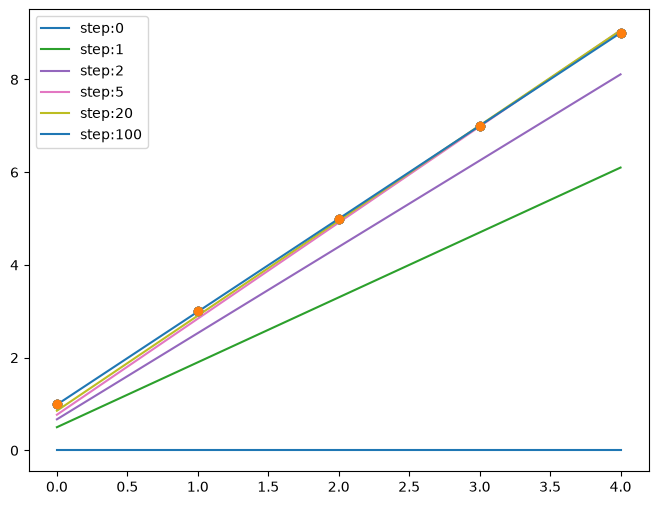

In [30]:
#B. The line learning
path, history = gd(0.05, 100)
steps = [0,1,2,5,20,100]
plt.figure(figsize=(8,6))
for i in steps:
    yhat = x* path[i][0] + path[i][1] 
    plt.plot(x, yhat, label=f'step:{i}')
    plt.plot(x, y, 'o')
    print(yhat)
    print(x)
    plt.legend()

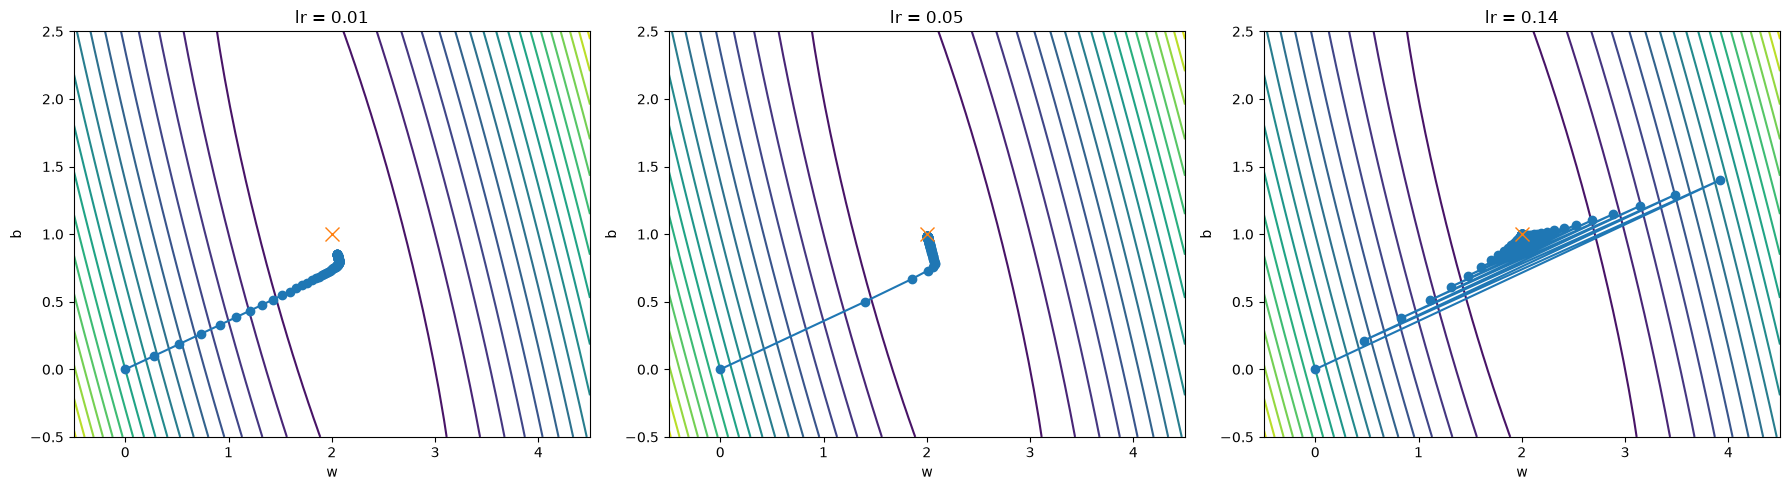

In [32]:
#C. The path on the loss surface.
w_values = np.linspace(-0.5, 4.5, 100)
b_values = np.linspace(-0.5, 2.5, 100)

W, B = np.meshgrid(w_values, b_values)

Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = mse(W[i, j], B[i, j])
        
        
lrs = [0.01, 0.05, 0.14]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, lr in zip(axes, lrs):

    path, history = gd(lr, 100)

    # Loss surface
    ax.contour(W, B, Z, levels=20)

    # GD path
    ax.plot(path[:, 0], path[:, 1], "o-")

    # Minimum
    ax.plot(2, 1, "x", markersize=10)

    ax.set_xlabel("w")
    ax.set_ylabel("b")
    ax.set_title(f"lr = {lr}")

plt.tight_layout()
plt.show()


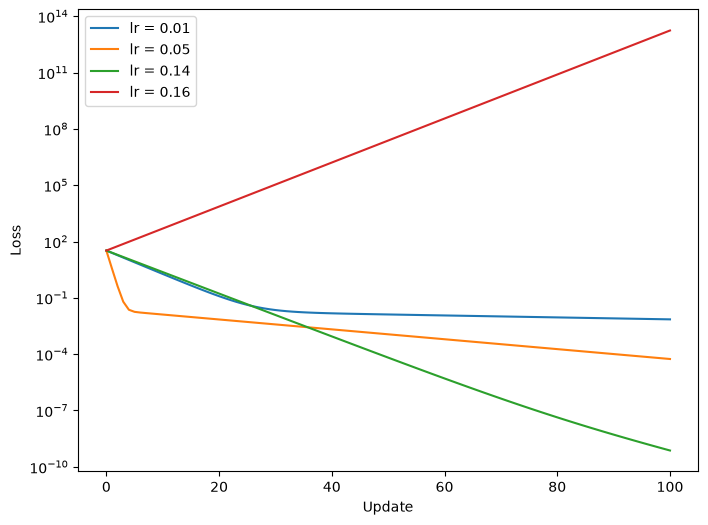

In [33]:
lrs = [0.01, 0.05, 0.14, 0.16]

plt.figure(figsize=(8, 6))

for lr in lrs:
    path, history = gd(lr, 100)

    plt.plot(history, label=f"lr = {lr}")

plt.yscale("log")
plt.xlabel("Update")
plt.ylabel("Loss")
plt.legend()
plt.show()